<a href="https://qworld.net" target="_blank" align="left"><img src="../../qworld/images/header.jpg"  align="left"></a>
$ \newcommand{\bra}[1]{\langle #1|} $
$ \newcommand{\ket}[1]{|#1\rangle} $
$ \newcommand{\braket}[2]{\langle #1|#2\rangle} $
$ \newcommand{\dot}[2]{ #1 \cdot #2} $
$ \newcommand{\biginner}[2]{\left\langle #1,#2\right\rangle} $
$ \newcommand{\mymatrix}[2]{\left( \begin{array}{#1} #2\end{array} \right)} $
$ \newcommand{\myvector}[1]{\mymatrix{c}{#1}} $
$ \newcommand{\myrvector}[1]{\mymatrix{r}{#1}} $
$ \newcommand{\mypar}[1]{\left( #1 \right)} $
$ \newcommand{\mybigpar}[1]{ \Big( #1 \Big)} $
$ \newcommand{\sqrttwo}{\frac{1}{\sqrt{2}}} $
$ \newcommand{\dsqrttwo}{\dfrac{1}{\sqrt{2}}} $
$ \newcommand{\onehalf}{\frac{1}{2}} $
$ \newcommand{\donehalf}{\dfrac{1}{2}} $
$ \newcommand{\hadamard}{ \mymatrix{rr}{ \sqrttwo & \sqrttwo \\ \sqrttwo & -\sqrttwo }} $
$ \newcommand{\vzero}{\myvector{1\\0}} $
$ \newcommand{\vone}{\myvector{0\\1}} $
$ \newcommand{\stateplus}{\myvector{ \sqrttwo \\  \sqrttwo } } $
$ \newcommand{\stateminus}{ \myrvector{ \sqrttwo \\ -\sqrttwo } } $
$ \newcommand{\myarray}[2]{ \begin{array}{#1}#2\end{array}} $
$ \newcommand{\X}{ \mymatrix{cc}{0 & 1 \\ 1 & 0}  } $
$ \newcommand{\I}{ \mymatrix{rr}{1 & 0 \\ 0 & 1}  } $
$ \newcommand{\Z}{ \mymatrix{rr}{1 & 0 \\ 0 & -1}  } $
$ \newcommand{\Htwo}{ \mymatrix{rrrr}{ \frac{1}{2} & \frac{1}{2} & \frac{1}{2} & \frac{1}{2} \\ \frac{1}{2} & -\frac{1}{2} & \frac{1}{2} & -\frac{1}{2} \\ \frac{1}{2} & \frac{1}{2} & -\frac{1}{2} & -\frac{1}{2} \\ \frac{1}{2} & -\frac{1}{2} & -\frac{1}{2} & \frac{1}{2} } } $
$ \newcommand{\CNOT}{ \mymatrix{cccc}{1 & 0 & 0 & 0 \\ 0 & 1 & 0 & 0 \\ 0 & 0 & 0 & 1 \\ 0 & 0 & 1 & 0} } $
$ \newcommand{\norm}[1]{ \left\lVert #1 \right\rVert } $
$ \newcommand{\pstate}[1]{ \lceil \mspace{-1mu} #1 \mspace{-1.5mu} \rfloor } $
$ \newcommand{\greenbit}[1] {\mathbf{{\color{green}#1}}} $
$ \newcommand{\bluebit}[1] {\mathbf{{\color{blue}#1}}} $
$ \newcommand{\redbit}[1] {\mathbf{{\color{red}#1}}} $
$ \newcommand{\brownbit}[1] {\mathbf{{\color{brown}#1}}} $
$ \newcommand{\blackbit}[1] {\mathbf{{\color{black}#1}}} $

# Ansatz Families and Expressivity

_Prepared by Claudia Zendejas-Morales_

After the feature map loads a classical sample into a quantum state, the **ansatz** defines the trainable part of the model. In QML, the ansatz determines which state transformations the model can learn, how many parameters it carries, how much entanglement it can create, and how difficult it may be to optimize in practice. This notebook introduces the main ansatz families used in variational QML and builds intuition for expressivity without confusing it with guaranteed performance.

## What an ansatz does

If the feature map prepares the input state

$$
|\psi_{\mathrm{in}}(\vec{x}^{\,j})\rangle = U_F(\vec{x}^{\,j})|0\rangle^{\otimes n}
$$

then a layered ansatz can be written as

$$
U_A(\boldsymbol{\theta}) = U_L(\boldsymbol{\theta}_L)\,U_{L-1}(\boldsymbol{\theta}_{L-1})\,\cdots\,U_1(\boldsymbol{\theta}_1)
$$

so the trainable output state becomes

$$
|\psi_{\mathrm{out}}(\vec{x}^{\,j}, \boldsymbol{\theta})\rangle = U_A(\boldsymbol{\theta})|\psi_{\mathrm{in}}(\vec{x}^{\,j})\rangle
$$

Here each $\boldsymbol{\theta}_\ell$ is the parameter vector of layer or block $U_\ell$, with $\ell = 1, \dots, L$, while $\boldsymbol{\theta}$ without a subscript denotes the full parameter collection of the ansatz. A convenient formal way to write that relation is

$$
\boldsymbol{\theta} = (\boldsymbol{\theta}_1, \boldsymbol{\theta}_2, \dots, \boldsymbol{\theta}_L),
\qquad
\boldsymbol{\theta}_\ell \in \mathbb{R}^{p_\ell}
$$

where $p_\ell$ is the number of trainable parameters in layer $\ell$.

The feature map and the ansatz play different roles. The feature map is data-dependent and not trainable. The ansatz is trainable and independent of the sample values once the state has been prepared. Together they define the quantum model family that will later be read through a measurement rule.


<div style="background:#fff1d6;color:#111111;border-left:6px solid #d98500;padding:12px 14px;border-radius:6px;">
<b>Ansatz expressivity is not automatic advantage</b><br>
A more expressive ansatz can represent a larger family of state transformations, but that does <b>not</b> mean it will train better, generalize better, or outperform a simpler circuit on a real device. In practice, expressivity, parameter count, depth, noise, and trainability must be balanced together.
</div>

## Two-local ansatze

A **two-local ansatz** alternates layers of single-qubit rotations with layers of two-qubit entangling gates. The subscript in $U_{\mathrm{2L}}$ stands for **two-local**: the circuit is built from local one-qubit trainable blocks together with explicitly two-qubit entangling blocks. In a simple $R_y$ version on $n$ qubits, it is useful to separate the local and entangling parts and write

$$
U_{\mathrm{2L}}(\boldsymbol{\theta}) = U_{\mathrm{rot}}^{(L)}\bigl(\boldsymbol{\theta}^{(L)}\bigr)
\prod_{\ell=1}^{L-1}
\left[
U_{\mathrm{ent}}^{(\ell)}\,U_{\mathrm{rot}}^{(\ell)}\bigl(\boldsymbol{\theta}^{(\ell)}\bigr)
\right]
$$

Here the product $\prod_{\ell=1}^{L-1}$ means that the same pattern is repeated layer by layer: for each $\ell = 1, \dots, L-1$, one applies the local trainable block $U_{\mathrm{rot}}^{(\ell)}\bigl(\boldsymbol{\theta}^{(\ell)}\bigr)$ together with the corresponding entangling block $U_{\mathrm{ent}}^{(\ell)}$. The final factor $U_{\mathrm{rot}}^{(L)}\bigl(\boldsymbol{\theta}^{(L)}\bigr)$ is written separately because many two-local templates end with a last rotation layer after the final entangling stage.

A common choice for the local trainable block is

$$
U_{\mathrm{rot}}^{(\ell)}\bigl(\boldsymbol{\theta}^{(\ell)}\bigr)
=
\bigotimes_{q=1}^{n} R_y\left(\theta_{q}^{(\ell)}\right)
$$

Here $q$ labels qubits, $\ell$ labels layers, and $U_{\mathrm{ent}}^{(\ell)}$ denotes the chosen entangling block for layer $\ell$, for example a linear chain, a circular pattern, or a fuller connectivity pattern. The expression for $U_{\mathrm{rot}}^{(\ell)}$ above uses only $R_y$ gates because that is one of the most common and easiest-to-read two-local choices, but in practice the local trainable block may also use other single-qubit families such as $R_x$, $R_z$, or short composites like $R_z R_y R_z$.

In the common language of circuit templates, one often speaks of $r$ entangling repetitions, which means $L = r+1$ local rotation layers. In this simple $R_y$ version, the total number of trainable angles is therefore

$$
\#\text{parameters} = nL = n(r+1)
$$

Two-local circuits are among the most common variational baselines because they are easy to interpret, easy to scale in small experiments, and flexible enough to support many QML tasks. Their main design choices are the single-qubit gate family, the entangling gate family, and the connectivity pattern.


<p align="center">
  <img align="center" style="display:block; margin-left: auto; margin-right: auto;" src="./images/ansatz-two-local.png" alt="Two-local ansatz" width="600"/>
</p>

The two-local idea is modular: in the circuit shown here there are $n=4$ qubits and $r=2$ entangling repetitions, so the number of rotation layers is $L=r+1=3$ (the figure labels them as Layers 0, 1, and 2). Since each layer contributes one $R_y$ angle per qubit, the total parameter count is $nL = 4\times 3 = 12$, while the linear entangling blocks propagate information across the register.

<p align="center">
  <img align="center" style="display:block; margin-left: auto; margin-right: auto;" src="./images/ansatz-entanglement-chain.png" alt="Entanglement chain" width="700"/>
</p>

A linear chain is only one possible pattern. Circular and all-to-all variants are also common, and they usually increase circuit depth or the number of entangling gates without necessarily changing the total number of trainable parameters.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from qiskit import transpile
from qiskit.circuit.library import real_amplitudes, efficient_su2, n_local, zz_feature_map
from qiskit.quantum_info import Statevector, state_fidelity
from qiskit.transpiler import CouplingMap

import pennylane as qml


Qiskit's `real_amplitudes` is a concrete and widely used example of a two-local ansatz. It combines layers of $R_y$ rotations with a chosen CNOT entanglement pattern. This makes it a good practical proxy for discussing how connectivity affects circuit cost.

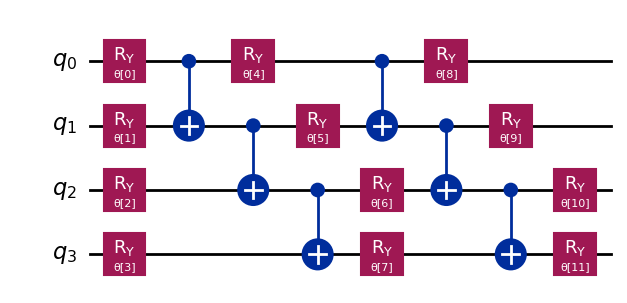


linear {'num_parameters': 12, 'depth': 8, 'ops': {'r': 12, 'cx': 6}}
circular {'num_parameters': 12, 'depth': 11, 'ops': {'r': 12, 'cx': 8}}
full {'num_parameters': 12, 'depth': 12, 'ops': {'r': 12, 'cx': 12}}


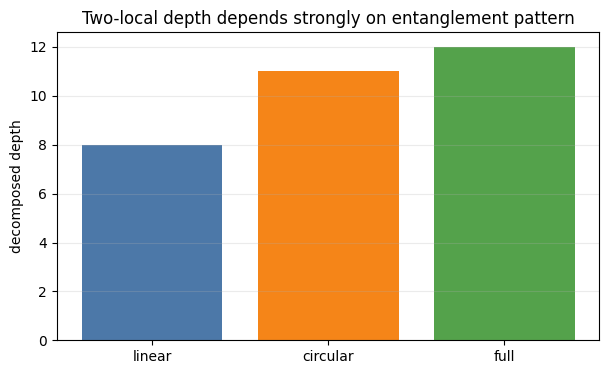

In [2]:
def summarize_circuit(circuit):
    decomposed = circuit.decompose()
    return {
        "num_parameters": circuit.num_parameters,
        "depth": decomposed.depth(),
        "ops": dict(decomposed.count_ops()),
    }

patterns = ["linear", "circular", "full"]
summary = {}

for pattern in patterns:
    circuit = real_amplitudes(num_qubits=4, reps=2, entanglement=pattern)
    summary[pattern] = summarize_circuit(circuit)

linear_example = real_amplitudes(num_qubits=4, reps=2, entanglement="linear")
display(linear_example.draw("mpl"))
print()
for pattern in patterns:
    print(pattern, summary[pattern])

plt.figure(figsize=(7, 4))
plt.bar(patterns, [summary[p]["depth"] for p in patterns], color=["#4c78a8", "#f58518", "#54a24b"])
plt.ylabel("decomposed depth")
plt.title("Two-local depth depends strongly on entanglement pattern")
plt.grid(axis="y", alpha=0.25)
plt.show()


In this comparison, the number of trainable parameters stays fixed because the rotation layout is the same in all three circuits. What changes is the entangling structure: denser connectivity usually means more two-qubit gates, greater depth, and potentially greater expressive power, but also higher hardware cost.

### Task 1 (coding): How do repetitions and connectivity change a two-local ansatz in PennyLane?

Implement a reusable **two-local ansatz** in PennyLane on **five wires**. Use one layer of $R_y$ rotations on every qubit, followed by a CNOT entangling block, and support the three connectivity patterns:

- `"linear"`
- `"circular"`
- `"full"`

Then study the six circuits obtained from:

- `reps in [1, 3]`
- `entanglement in ["linear", "circular", "full"]`

For each circuit:

- record the number of trainable parameters;
- use PennyLane tools to inspect circuit depth and operation counts;
- make one compact visualization that compares the depths;
- draw at least one representative circuit.

Then answer two short questions:

- Which design change increases the parameter count?
- Which design change increases the circuit cost even when the parameter count stays the same?

Official references that may help:

- <a href="https://docs.pennylane.ai/en/stable/code/api/pennylane.qnode.html"><code>qml.qnode</code></a>
- <a href="https://docs.pennylane.ai/en/stable/code/api/pennylane.RY.html"><code>qml.RY</code></a>
- <a href="https://docs.pennylane.ai/en/stable/code/api/pennylane.CNOT.html"><code>qml.CNOT</code></a>
- <a href="https://docs.pennylane.ai/en/stable/code/api/pennylane.specs.html"><code>qml.specs</code></a>
- <a href="https://docs.pennylane.ai/en/stable/code/api/pennylane.draw.html"><code>qml.draw</code></a>


<div style="background:#e8f1ff;color:#111111;border-left:6px solid #2f6fed;padding:12px 14px;border-radius:6px;">
<b>Task 1 solution:</b> <a href="03-ansatz-families-and-expressivity-solutions.ipynb#task1-solution">Click here for Task 1 solution</a>
</div>

In [3]:
# Task 1 starter
n_wires = 5
reps_list = [1, 3]
entanglement_patterns = ["linear", "circular", "full"]

def entangling_layer(pattern, wires):
    # TODO: implement the CNOT pattern for "linear", "circular", and "full"
    pass

def two_local_ansatz(weights, pattern, wires):
    # TODO: apply one RY layer per repetition, followed by one entangling layer
    # TODO: finish with one last RY layer
    pass

# Suggested next steps:
# 1. create a qnode that applies two_local_ansatz and returns qml.probs
# 2. use qml.specs to collect depth and operation counts for the 6 cases
# 3. make one compact depth comparison plot
# 4. draw at least one representative circuit and answer the conceptual questions


PennyLane also provides built-in layer templates for this general family. In particular, <a href="https://docs.pennylane.ai/en/stable/code/api/pennylane.BasicEntanglerLayers.html"><code>qml.BasicEntanglerLayers</code></a> is a useful near-parallel reference to Qiskit's <a href="https://quantum.cloud.ibm.com/docs/en/api/qiskit/qiskit.circuit.library.real_amplitudes"><code>real_amplitudes</code></a>: it alternates one-parameter single-qubit rotations with CNOT entanglers and can be used with `rotation=qml.RY`. The main structural difference is that `qml.BasicEntanglerLayers` comes with a built-in closed-chain entangling pattern, so it does <b>not</b> expose the same `"linear"`, `"circular"`, and `"full"` selector used in Qiskit. That is why Task 1 asks for a custom implementation, while the next task asks you to explore the built-in PennyLane template directly.

### Task 2 (optional, coding): Explore `qml.BasicEntanglerLayers` in PennyLane

Use `qml.BasicEntanglerLayers` on **five wires** with `rotation=qml.RY` to study a built-in PennyLane template that is broadly similar to the two-local family discussed above.

Work with:

- `reps in [1, 3]`

For each case:

- determine the required weight shape with `qml.BasicEntanglerLayers.shape(...)`;
- build one explicit weight tensor;
- draw the circuit;
- report the total number of trainable parameters;
- use PennyLane tools to inspect circuit depth and operation counts.

Then explain briefly why this template is only *approximately* analogous to Qiskit's `real_amplitudes`, rather than a strict one-to-one equivalent.

Official references that may help:

- <a href="https://docs.pennylane.ai/en/stable/code/api/pennylane.BasicEntanglerLayers.html"><code>qml.BasicEntanglerLayers</code></a>
- <a href="https://docs.pennylane.ai/en/stable/code/api/pennylane.qnode.html"><code>qml.qnode</code></a>
- <a href="https://docs.pennylane.ai/en/stable/code/api/pennylane.specs.html"><code>qml.specs</code></a>
- <a href="https://docs.pennylane.ai/en/stable/code/api/pennylane.draw.html"><code>qml.draw</code></a>


<div style="background:#e8f1ff;color:#111111;border-left:6px solid #2f6fed;padding:12px 14px;border-radius:6px;">
<b>Task 2 solution:</b> <a href="03-ansatz-families-and-expressivity-solutions.ipynb#task2-solution">Click here for Task 2 solution</a>
</div>

In [4]:
# Task 2 starter
n_wires = 5
reps_list = [1, 3]

# TODO:
# 1. use qml.BasicEntanglerLayers.shape to get the required weight shape
# 2. build one explicit weight tensor for each value of reps
# 3. define a QNode that applies qml.BasicEntanglerLayers with rotation=qml.RY
# 4. draw the circuits for reps=1 and reps=3
# 5. report parameter count, depth, and operation counts
# 6. explain why this template is only approximately equivalent to Qiskit's real_amplitudes


## Hardware-efficient ansatze

A **hardware-efficient ansatz** is not one single circuit template. It is a design principle: choose rotation blocks and entangling blocks that match the native gate set and connectivity of the target device as closely as possible. A convenient abstract form is

$$
U_{\mathrm{HE}}(\boldsymbol{\theta}) = \prod_{\ell=1}^{L}
\left[
U_{\mathrm{ent}}^{(\ell)}(G)\,U_{\mathrm{loc}}^{(\ell)}\!\bigl(\boldsymbol{\theta}^{(\ell)}\bigr)
\right]
$$

where $G = (V, E)$ is the hardware connectivity graph, with one vertex in $V$ for each physical qubit and one edge in $E$ for each native two-qubit connection available on the device, and

$$
U_{\mathrm{loc}}^{(\ell)}\!\bigl(\boldsymbol{\theta}^{(\ell)}\bigr)
=
\bigotimes_{q=1}^{n} U_q\!\bigl(\boldsymbol{\theta}_{q}^{(\ell)}\bigr)
$$

Here $U_q\!\bigl(\boldsymbol{\theta}_{q}^{(\ell)}\bigr)$ denotes the local trainable block applied to qubit $q$ at layer $\ell$, while $U_{\mathrm{ent}}^{(\ell)}(G)$ is an entangling block that respects the hardware graph $G$. So $G$ is not just a decorative label: it encodes which qubit pairs can interact directly, which pairs would require swap-routing or compilation overhead, and therefore which circuit layouts are realistic on the target hardware. In other words, a hardware-efficient ansatz tries to spend its circuit depth on gates that the device can implement naturally, instead of paying extra compilation overhead for an abstract ideal design.


<p align="center">
  <img align="center" style="display:block; margin-left: auto; margin-right: auto;" src="./images/ansatz-hardware-efficient.png" alt="Hardware-efficient ansatz" width="600"/>
</p>

This kind of circuit is called hardware-efficient because the entangling pattern is adapted to available connectivity rather than assuming arbitrary all-to-all interactions.

<p align="center">
  <img align="center" style="display:block; margin-left: auto; margin-right: auto;" src="./images/ansatz-aspen-system-topology.png" alt="Aspen system topology" width="500"/>
</p>

A hardware graph such as the Aspen topology makes the role of $G$ concrete. Each node represents a physical qubit, and each edge marks a pair of qubits that can be coupled directly by the device. If an ansatz asks for an interaction between qubits that are not adjacent in $G$, the compiler must usually insert extra routing operations, which increases depth and noise. That is exactly why hardware-efficient design starts from the connectivity graph rather than from an abstract all-to-all circuit picture.

<div style="background:#fff1d6;color:#111111;border-left:6px solid #d98500;padding:12px 14px;border-radius:6px;">
<b>Hardware-efficient is a strategy, not a unique circuit</b><br>
A circuit can be called hardware-efficient because of how it is designed relative to a device, not because it belongs to one universal ansatz family. Two devices with different native gates or coupling graphs may lead to different hardware-efficient choices even for the same learning task.
</div>

Qiskit's <a href="https://quantum.cloud.ibm.com/docs/en/api/qiskit/qiskit.circuit.library.efficient_su2"><code>efficient_su2</code></a> is a useful concrete example for this discussion. It enriches the single-qubit block compared with `real_amplitudes` by using a larger local rotation family, while still exposing an entanglement pattern that can be chosen to match a hardware graph. In a genuinely hardware-aware workflow, however, the key step is not only selecting a pattern such as `entanglement="linear"`, but also checking that this pattern matches a connected subgraph of the device connectivity and then compiling the circuit against that graph, for example with <a href="https://quantum.cloud.ibm.com/docs/en/api/qiskit/compiler"><code>transpile(..., coupling_map=...)</code></a> and <a href="https://quantum.cloud.ibm.com/docs/api/qiskit/2.2/qiskit.transpiler.CouplingMap"><code>CouplingMap</code></a>.

In PennyLane there is no single built-in class that should be presented as <i>the</i> hardware-efficient ansatz, because hardware-efficient design is a strategy rather than one universal template. This is also why the example below is written manually instead of with <a href="https://docs.pennylane.ai/en/stable/code/api/pennylane.BasicEntanglerLayers.html"><code>qml.BasicEntanglerLayers</code></a>: that template has a built-in ring-like entangling pattern and does not expose an argument for an arbitrary hardware graph $G$, so it is not the right tool when the goal is to illustrate a specific device connectivity.


real_amplitudes (abstract template):



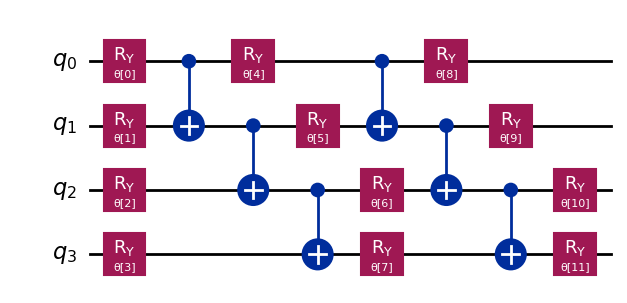


efficient_su2 (abstract template):



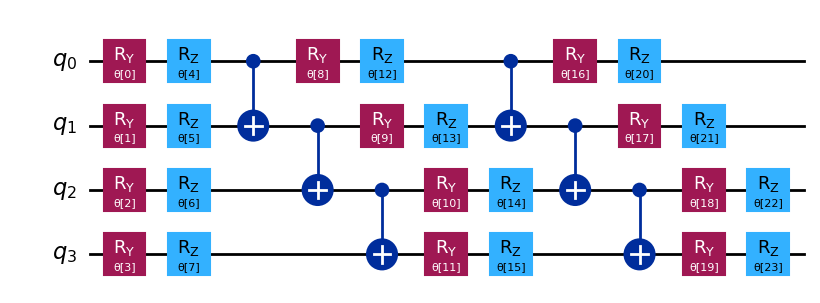


efficient_su2 compiled against a mismatched but connected hardware graph:



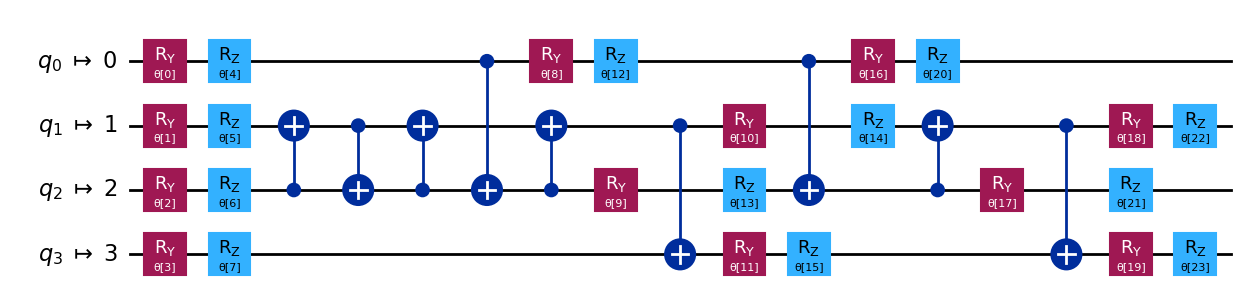

hardware graph edges: EdgeList[(0, 2), (2, 0), (2, 1), (1, 2), (1, 3), (3, 1)]

real_amplitudes {'num_parameters': 12, 'depth': 8, 'ops': {'r': 12, 'cx': 6}}
efficient_su2 {'num_parameters': 24, 'depth': 11, 'ops': {'r': 12, 'p': 12, 'cx': 6}}
efficient_su2_hardware {'num_parameters': 24, 'depth': 14, 'ops': {'r': 12, 'p': 12, 'cx': 9}}


In [5]:
real_amp = real_amplitudes(num_qubits=4, reps=2, entanglement="linear")
eff_su2 = efficient_su2(num_qubits=4, reps=2, entanglement="linear", su2_gates=["ry", "rz"])

# This connected graph is intentionally not aligned with the logical chain 0-1-2-3
# Under the fixed initial layout below, transpilation must insert routing to respect it
hardware_zigzag = CouplingMap([[0, 2], [2, 0], [2, 1], [1, 2], [1, 3], [3, 1]])

eff_su2_hardware = transpile(
    eff_su2,
    basis_gates=["ry", "rz", "cx"],
    coupling_map=hardware_zigzag,
    initial_layout=[0, 1, 2, 3],
    optimization_level=0,
)

print("real_amplitudes (abstract template):\n")
display(real_amp.draw("mpl"))
print("\nefficient_su2 (abstract template):\n")
display(eff_su2.draw("mpl"))
print("\nefficient_su2 compiled against a mismatched but connected hardware graph:\n")
display(eff_su2_hardware.draw("mpl"))

comparison = {
    "real_amplitudes": summarize_circuit(real_amp),
    "efficient_su2": summarize_circuit(eff_su2),
    "efficient_su2_hardware": summarize_circuit(eff_su2_hardware),
}
print("hardware graph edges:", hardware_zigzag.get_edges())
print()
for name, info in comparison.items():
    print(name, info)


The contrast matters. The first two circuits are still abstract ansatz templates, while the third one makes the hardware-aware constraint explicit by compiling `efficient_su2` against a concrete coupling graph that does not match the logical linear chain under the chosen layout. In that case, the transpiler must insert routing operations so that the circuit respects the edges of $G$. This makes the hardware cost visible in the drawing itself. In a good hardware-efficient design, one tries to choose an ansatz and a qubit layout that reduce this kind of routing overhead from the start.


In [6]:
n_wires = 4
# A small connected graph that is intentionally not the simple chain 0-1-2-3.
hardware_edges = [(0, 2), (2, 1), (1, 3)]
weights_he = np.linspace(0.1, 1.6, num=2 * n_wires).reshape(2, n_wires)
dev_he = qml.device("default.qubit", wires=n_wires)

@qml.qnode(dev_he)
def edge_aware_hardware_ansatz(weights):
    for q in range(n_wires):
        qml.RY(weights[0, q], wires=q)
        qml.RZ(weights[1, q], wires=q)
    for control, target in hardware_edges:
        qml.CNOT(wires=[control, target])
    return qml.probs(wires=range(n_wires))

print("PennyLane edge-aware ansatz (compact view):\n")
print(qml.draw(edge_aware_hardware_ansatz)(weights_he))
print("\nPennyLane edge-aware ansatz (device-level view):\n")
print(qml.draw(edge_aware_hardware_ansatz, level="device")(weights_he))
print("\nchosen hardware edges:", hardware_edges)
print("\nresources:")
print(qml.specs(edge_aware_hardware_ansatz)(weights_he)["resources"])


PennyLane edge-aware ansatz (compact view):

0: ──RY(0.10)──RZ(0.96)─╭●───────┤ ╭Probs
1: ──RY(0.31)──RZ(1.17)─│──╭X─╭●─┤ ├Probs
2: ──RY(0.53)──RZ(1.39)─╰X─╰●─│──┤ ├Probs
3: ──RY(0.74)──RZ(1.60)───────╰X─┤ ╰Probs

PennyLane edge-aware ansatz (device-level view):

0: ──RY(0.10)──RZ(0.96)─╭●───────┤ ╭Probs
1: ──RY(0.31)──RZ(1.17)─│──╭X─╭●─┤ ├Probs
2: ──RY(0.53)──RZ(1.39)─╰X─╰●─│──┤ ├Probs
3: ──RY(0.74)──RZ(1.60)───────╰X─┤ ╰Probs

chosen hardware edges: [(0, 2), (2, 1), (1, 3)]

resources:
Total wire allocations: 4
Total gates: 11
Circuit depth: 5

Gate types:
  RY: 4
  RZ: 4
  CNOT: 3

Measurements:
  probs(all wires): 1


This PennyLane example is intentionally short but more topology-aware than a generic layered template. The entangling block is built only from the edges in `hardware_edges`, and here those edges form a small zigzag-style connected graph rather than the trivial chain `0-1-2-3`. That makes the hardware choice visible in the circuit itself. This is the same design principle as in the Qiskit example above: the ansatz is considered hardware-efficient not because of its name, but because its two-qubit interactions are selected to respect the available connectivity.


## Manual design, transpilation, and hybrid practice

When targeting real quantum hardware, one does not usually face a strict all-or-nothing choice between fully manual circuits and fully automatic compilation. In practice, there are three common levels of control.

**Manual design** means that the entangling pattern is chosen explicitly from the hardware graph $G$, as in the short topology-aware examples above. This gives the clearest control over which two-qubit interactions are allowed and is often useful when one wants a circuit that already respects a known device topology.

**Transpilation** means writing a more abstract circuit first and then letting the backend or compiler adapt it to the target device. In Qiskit this appears naturally through tools such as `transpile(...)`, and in PennyLane it can happen through the device plugin itself or through transforms such as <a href="https://docs.pennylane.ai/en/stable/_modules/pennylane/transforms/transpile.html"><code>qml.transforms.transpile</code></a>. This is convenient, but if the original ansatz is poorly matched to the hardware graph, the compiled circuit may acquire extra routing gates and unnecessary depth.

**Hybrid practice** is usually the most realistic approach: design the ansatz at a high level, but already bias its entangling structure toward the target hardware, and then let compilation handle the remaining low-level details. This is typically the best compromise between portability and hardware awareness across frameworks. In particular, it matches the broader device-oriented workflow emphasized in PennyLane, where the same circuit can be attached to different backends while still allowing backend-specific execution choices, and it is also aligned with Qiskit's hardware-oriented transpilation workflow. Useful references are the PennyLane device guide at <a href="https://pennylane.ai/devices/">pennylane.ai/devices</a>, the blog discussion <a href="https://pennylane.ai/blog/2023/01/how-to-choose-your-device/">How to choose your device</a>, Qiskit's <a href="https://quantum.cloud.ibm.com/docs/guides/transpile">Introduction to transpilation</a>, and the Qiskit guide <a href="https://quantum.cloud.ibm.com/docs/en/guides/execute-on-hardware">Execute on target hardware</a>.


<div style="background:#fff1d6;color:#111111;border-left:6px solid #d98500;padding:12px 14px;border-radius:6px;">
<b>Practical rule of thumb</b><br>
If the target hardware is already known, it is usually better to bias the ansatz toward its connectivity graph first and let transpilation solve only the remaining compilation details. If the target hardware is still undecided, a more abstract ansatz may be acceptable during prototyping, but one should still expect to revisit connectivity before serious hardware execution.
</div>

<div style="background:#fff1d6;color:#111111;border-left:6px solid #d98500;padding:12px 14px;border-radius:6px;">
<b>Scope of this tutorial</b><br>
In this QML tutorial, the examples are developed at the simulation level. So although hardware connectivity is an important practical consideration in real deployments, we will not optimize the examples in this tutorial for a specific device topology or coupling map. This topic is discussed here only because hardware-efficient ansatze are defined precisely by their relationship to the hardware graph; outside this discussion, the tutorial examples will not be constrained by backend-specific connectivity.
</div>

## Strongly entangling layers

A **strongly entangling layers** ansatz uses a richer single-qubit block together with a tunable entangling range. For $n$ qubits and $L$ layers, one convenient decomposition is

$$
U_{\mathrm{SEL}}(\boldsymbol{\theta}, \mathbf{r}) = \prod_{\ell=1}^{L}
\left[
U_{\mathrm{ent}}^{(\ell)}(r_\ell)\,U_{\mathrm{loc}}^{(\ell)}\!\bigl(\boldsymbol{\theta}^{(\ell)}\bigr)
\right]
$$

where the local block of layer $\ell$ is

$$
U_{\mathrm{loc}}^{(\ell)}\!\bigl(\boldsymbol{\theta}^{(\ell)}\bigr)
=
\prod_{q=1}^{n} R_z\!\left(\theta_{q,1}^{(\ell)}\right)
R_y\!\left(\theta_{q,2}^{(\ell)}\right)
R_z\!\left(\theta_{q,3}^{(\ell)}\right)
$$

and the entangling block is

$$
U_{\mathrm{ent}}^{(\ell)}(r_\ell)
=
\prod_{q=1}^{n} \operatorname{CNOT}_{q,\,((q+r_\ell-1) \bmod n)+1}
$$

Here $r_\ell$ is the entangling range of layer $\ell$, and $\mathbf{r} = (r_1, \dots, r_L)$ collects all layer ranges. Since each qubit contributes three trainable angles per layer, this ansatz uses

$$
\#\text{parameters} = 3nL
$$

Its main purpose is to create a flexible balance between local trainability and nonlocal coupling structure.


<p align="center">
  <img align="center" style="display:block; margin-left: auto; margin-right: auto;" src="./images/ansatz-strongly-entangling-layers.png" alt="Strongly entangling layers" width="800"/>
</p>

The range parameter changes which qubits are coupled inside each layer, so the same ansatz family can interpolate between more local and more global interaction patterns. In the figure shown here there are $n=4$ qubits and $L=2$ layers, and each qubit carries three trainable angles per layer through the $R_z R_y R_z$ block. So the total number of trainable parameters is $3nL = 3 \times 4 \times 2 = 24$. Here the two layers use respective ranges $1$ and $2$, so in the notation means $\mathbf{r} = (r_1, r_2) = (1, 2)$: the first entangling block uses range $r_1=1$, while the second uses range $r_2=2$. In the displayed version of the circuit, $r_\ell$ appears only in the entangling block because that block is written with CNOT gates.

More generally, however, strongly entangling layers are not restricted to CNOT as the only two-qubit option: the family can also be defined with another fixed two-qubit entangler, such as CZ. The range values still play the same role of deciding which qubit pairs are coupled in each layer, and they are not additional trainable parameters like the angles $\theta_{q,1}^{(\ell)}, \theta_{q,2}^{(\ell)}, \theta_{q,3}^{(\ell)}$.

PennyLane includes `qml.StronglyEntanglingLayers`, which is a natural framework to explore this family. We will keep the example state-based and structural here; detailed readout choices belong to the next notebook.

In [7]:
n_wires = 4
n_layers = 2
shape = qml.StronglyEntanglingLayers.shape(n_layers=n_layers, n_wires=n_wires)
weights = np.linspace(0.1, 1.9, num=np.prod(shape)).reshape(shape)

dev_sel = qml.device("default.qubit", wires=n_wires)

@qml.qnode(dev_sel)
def sel_state(weights, ranges):
    qml.StronglyEntanglingLayers(weights=weights, wires=range(n_wires), ranges=ranges)
    return qml.state()

print("weights shape:", shape)
print("\nrange pattern [1, 1] (device-level view):\n")
print(qml.draw(sel_state, level="device")(weights, [1, 1]))
print("\nrange pattern [1, 2] (device-level view):\n")
print(qml.draw(sel_state, level="device")(weights, [1, 2]))


weights shape: (2, 4, 3)

range pattern [1, 1] (device-level view):

0: ──Rot(0.10,0.18,0.26)─╭●───────╭X──Rot(1.04,1.12,1.20)─╭●───────╭X─┤ ╭State
1: ──Rot(0.33,0.41,0.49)─╰X─╭●────│───Rot(1.27,1.35,1.43)─╰X─╭●────│──┤ ├State
2: ──Rot(0.57,0.65,0.73)────╰X─╭●─│───Rot(1.51,1.59,1.67)────╰X─╭●─│──┤ ├State
3: ──Rot(0.80,0.88,0.96)───────╰X─╰●──Rot(1.74,1.82,1.90)───────╰X─╰●─┤ ╰State

range pattern [1, 2] (device-level view):

0: ──Rot(0.10,0.18,0.26)─╭●───────╭X──Rot(1.04,1.12,1.20)─╭●────╭X────┤ ╭State
1: ──Rot(0.33,0.41,0.49)─╰X─╭●────│───Rot(1.27,1.35,1.43)─│──╭●─│──╭X─┤ ├State
2: ──Rot(0.57,0.65,0.73)────╰X─╭●─│───Rot(1.51,1.59,1.67)─╰X─│──╰●─│──┤ ├State
3: ──Rot(0.80,0.88,0.96)───────╰X─╰●──Rot(1.74,1.82,1.90)────╰X────╰●─┤ ╰State


The reason for comparing the two circuits is that they use the same number of qubits, the same number of layers, and the same trainable weights, but a different **range schedule**. The pattern `[1, 1]` keeps both entangling layers local in the same way, while `[1, 2]` changes only the second layer so that it couples a different set of qubit pairs. Once the template is drawn at device level, that structural difference becomes visible directly in the entangling gates. This is one reason strongly entangling layers are attractive for experimentation: the same template can be made more local or more global without redefining the whole ansatz family.


### Task 3 (coding): Build a strongly-entangling-style ansatz in Qiskit

Qiskit does not provide a built-in template called `StronglyEntanglingLayers`, but its <a href="https://quantum.cloud.ibm.com/docs/api/qiskit/qiskit.circuit.library.n_local"><code>n_local</code></a> constructor is flexible enough to build a close analogue. Use it on **five qubits** with:

- `rotation_blocks=["rz", "ry", "rz"]`
- `entanglement_blocks="cx"`
- `skip_final_rotation_layer=True`
- `reps=3`

Construct two circuits whose layer-wise range schedules are:

- `ranges_a = [1, 1, 1]`
- `ranges_b = [1, 2, 1]`

To do this, define the entanglement pattern of each repetition explicitly from the range values, so that layer $\ell$ couples qubit $q$ to qubit $(q+r_\ell) \bmod n$.

For each circuit:

- draw the circuit;
- report the total number of trainable parameters;
- decompose once and record the depth and operation counts;
- explain what changes structurally when the middle layer uses range `2` instead of range `1`.

Official references that may help:

- <a href="https://quantum.cloud.ibm.com/docs/api/qiskit/qiskit.circuit.library.n_local"><code>n_local</code></a>
- <a href="https://quantum.cloud.ibm.com/docs/guides/circuit-library">Qiskit circuit library guide</a>


<div style="background:#e8f1ff;color:#111111;border-left:6px solid #2f6fed;padding:12px 14px;border-radius:6px;">
<b>Task 3 solution:</b> <a href="03-ansatz-families-and-expressivity-solutions.ipynb#task3-solution">Click here for Task 3 solution</a>
</div>

In [8]:
# Task 3 starter
n_wires = 5
ranges_a = [1, 1, 1]
ranges_b = [1, 2, 1]

def range_entanglement(n_wires, r):
    # TODO: return the entangler map for one layer with range r
    pass

# TODO:
# 1. use n_local to build one circuit for ranges_a and another for ranges_b
# 2. use rotation_blocks=["rz", "ry", "rz"] and entanglement_blocks="cx"
# 3. set skip_final_rotation_layer=True so the layer structure matches the strongly-entangling-style form
# 4. draw both circuits and report parameter count, depth, and operation counts
# 5. explain what changes structurally when the middle layer uses range 2


## Other structured ansatze

Two-local, hardware-efficient, and strongly entangling layers are common practical families, but they are not the only options. Structured alternatives such as **tree-tensor ansatze** can be useful when the problem suggests hierarchical correlations or when one wants a more restricted connectivity pattern. In QML, ansatz design is often problem-dependent: chemistry, kernels, generative modeling, and hardware demonstrations may all motivate different choices.

<p align="center">
  <img align="center" style="display:block; margin-left: auto; margin-right: auto;" src="./images/ansatz-tree-tensor.png" alt="Tree-tensor ansatz" width="600"/>
</p>

A tree-tensor ansatz is a useful visual example of a more structured architecture. Instead of repeating the same local-and-entangling pattern uniformly across all qubits, it organizes interactions hierarchically, which can be appealing when the problem suggests multi-scale or tree-like correlations.


## Expressivity intuition

A convenient way to talk about ansatz expressivity is to fix an input state and consider the set of states reachable by changing the trainable parameters:

$$
\mathcal{S}_A\bigl(|\psi_{\mathrm{in}}\rangle\bigr) = \left\{ U_A(\boldsymbol{\theta})|\psi_{\mathrm{in}}\rangle : \boldsymbol{\theta} \in \Theta \right\}
$$

Here $\mathcal{S}_A\bigl(|\psi_{\mathrm{in}}\rangle\bigr)$ is the **reachable-state set** associated with ansatz $A$ and the fixed input state $|\psi_{\mathrm{in}}\rangle$. The symbol $\Theta$ denotes the parameter domain of the ansatz, that is, the set of trainable parameter values that are allowed to vary. If the ansatz has $P$ real trainable parameters, then one often has $\Theta \subseteq \mathbb{R}^P$.

If one later chooses an observable $O$, the corresponding model family induces scalar outputs of the form

$$
f_A(\vec{x}^{\,j}, \boldsymbol{\theta}) = \langle \psi_{\mathrm{out}}(\vec{x}^{\,j}, \boldsymbol{\theta}) | O | \psi_{\mathrm{out}}(\vec{x}^{\,j}, \boldsymbol{\theta}) \rangle
$$

To build a practical heuristic, we can sample several parameter settings from $\Theta$. Let those sampled settings be $\boldsymbol{\theta}^{(1)}, \dots, \boldsymbol{\theta}^{(T)}$, where $T$ is the number of sampled parameter settings. For each sampled setting, define the corresponding output state

$$
|\psi_a\rangle := U_A\!\left(\boldsymbol{\theta}^{(a)}\right)|\psi_{\mathrm{in}}\rangle,
\qquad a = 1, \dots, T
$$

so $|\psi_a\rangle$ is simply the state produced by the ansatz when the $a$-th sampled parameter setting is used. One convenient summary statistic is then the mean pairwise fidelity

$$
\bar{F} = \frac{2}{T(T-1)} \sum_{1 \leq a < b \leq T} |\langle \psi_a | \psi_b \rangle|^2
$$

A lower value of $\bar{F}$ suggests that the sampled states are, on average, more spread out in Hilbert space for that fixed input. In this notebook we use this only as intuition. The next notebook will discuss observables, measurement, and readout more carefully. For now, the key idea is that a richer ansatz can spread reachable states more broadly in Hilbert space, but that does not by itself guarantee useful learning.


<div style="background:#fff1d6;color:#111111;border-left:6px solid #d98500;padding:12px 14px;border-radius:6px;">
<b>Expressive in principle does not mean useful in practice</b><br>
An ansatz can look very expressive because it reaches many states under parameter variation, yet still be hard to optimize, too noisy to run deeply, or poorly matched to the inductive bias of the learning task. Expressivity is one ingredient of model design, not the whole story.
</div>

<div style="background:#fff1d6;color:#111111;border-left:6px solid #d98500;padding:12px 14px;border-radius:6px;">
<b>About the fidelity heuristic</b><br>
For two pure states $|\phi\rangle$ and $|\psi\rangle$, the quantity $|\langle \phi | \psi \rangle|^2$ is their fidelity. It lies in $[0,1]$: values close to $1$ mean the states are very similar, while values close to $0$ mean they are nearly orthogonal. In this notebook fidelity is used only as a rough geometric heuristic for expressivity, not as a direct measure of task performance.
</div>

One simple heuristic is to keep the input state fixed, sample many random parameter settings, and compare how similar the resulting states are. If a family tends to generate states with lower pairwise fidelity on average, that suggests it explores a broader region of state space. This is only a heuristic, but it is useful for building intuition.

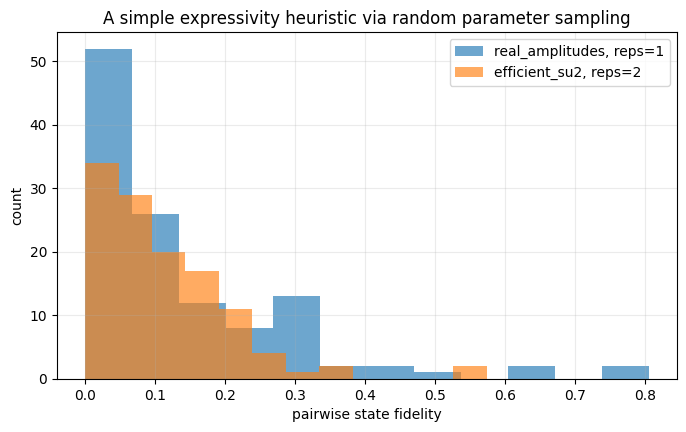

mean pairwise fidelity, real_amplitudes: 0.13864665966678252
mean pairwise fidelity, efficient_su2: 0.11476328226386447


In [9]:
sample = [0.30, 0.80, 1.10]
encoded_input = zz_feature_map(feature_dimension=3, reps=1, entanglement="linear").assign_parameters(sample)

ansatz_a = real_amplitudes(num_qubits=3, reps=1, entanglement="linear")
ansatz_b = efficient_su2(num_qubits=3, reps=2, entanglement="linear", su2_gates=["ry", "rz"])

rng = np.random.default_rng(7)

def sampled_fidelities(encoded_circuit, ansatz_template, n_samples=16):
    states = []
    for _ in range(n_samples):
        theta = rng.uniform(0.0, 2 * np.pi, ansatz_template.num_parameters)
        circuit = encoded_circuit.compose(ansatz_template.assign_parameters(theta))
        states.append(Statevector.from_instruction(circuit))

    fidelities = []
    for i in range(len(states)):
        for j in range(i + 1, len(states)):
            fidelities.append(state_fidelity(states[i], states[j]))
    return np.array(fidelities)

fids_a = sampled_fidelities(encoded_input, ansatz_a)
fids_b = sampled_fidelities(encoded_input, ansatz_b)

plt.figure(figsize=(8, 4.5))
plt.hist(fids_a, bins=12, alpha=0.65, label="real_amplitudes, reps=1")
plt.hist(fids_b, bins=12, alpha=0.65, label="efficient_su2, reps=2")
plt.xlabel("pairwise state fidelity")
plt.ylabel("count")
plt.title("A simple expressivity heuristic via random parameter sampling")
plt.grid(alpha=0.25)
plt.legend()
plt.show()

print("mean pairwise fidelity, real_amplitudes:", float(np.mean(fids_a)))
print("mean pairwise fidelity, efficient_su2:", float(np.mean(fids_b)))

If one family shows a visibly broader fidelity distribution or a lower mean fidelity, that suggests it spreads parameterized states more widely for the same fixed input. This is the kind of evidence one may use to build intuition about expressivity. It is not a theorem about task performance, and it should always be balanced against depth and trainability.

### Task 4 (coding): Estimate an expressivity heuristic in PennyLane with state fidelity

Use PennyLane to compare two versions of `qml.BasicEntanglerLayers` acting on the same fixed encoded input state. Work on **three wires** and compare:

- `reps=1`
- `reps=3`

Prepare the same classical sample in both cases with a simple angle embedding, then sample several random weight settings for each ansatz. Use <a href="https://docs.pennylane.ai/en/stable/code/api/pennylane.math.fidelity_statevector.html"><code>qml.math.fidelity_statevector</code></a> to compute pairwise fidelities among the resulting states.

For each ansatz family:

- report the weight shape and total number of trainable parameters;
- compute the mean pairwise fidelity over the sampled states;
- inspect the circuit depth with PennyLane tools;
- compare the heuristic result with the extra circuit cost.

Your conclusion should discuss both sides: which family looks more expressive under this heuristic, and what additional cost is being paid for that gain.

Official references that may help:

- <a href="https://docs.pennylane.ai/en/stable/code/api/pennylane.BasicEntanglerLayers.html"><code>qml.BasicEntanglerLayers</code></a>
- <a href="https://docs.pennylane.ai/en/stable/code/api/pennylane.AngleEmbedding.html"><code>qml.AngleEmbedding</code></a>
- <a href="https://docs.pennylane.ai/en/stable/code/api/pennylane.state.html"><code>qml.state</code></a>
- <a href="https://docs.pennylane.ai/en/stable/code/api/pennylane.math.fidelity_statevector.html"><code>qml.math.fidelity_statevector</code></a>
- <a href="https://docs.pennylane.ai/en/stable/code/api/pennylane.specs.html"><code>qml.specs</code></a>


<div style="background:#e8f1ff;color:#111111;border-left:6px solid #2f6fed;padding:12px 14px;border-radius:6px;">
<b>Task 4 solution:</b> <a href="03-ansatz-families-and-expressivity-solutions.ipynb#task4-solution">Click here for Task 4 solution</a>
</div>

In [10]:
# Task 4 starter
sample = np.array([0.30, 0.80, 1.10])
n_wires = 3
reps_list = [1, 3]

def embedded_basic_entangler(sample, weights):
    # TODO: apply angle embedding and then qml.BasicEntanglerLayers
    pass

def sampled_fidelities_pennylane(sample, reps, n_samples=16, seed=11):
    # TODO: sample random weights, collect output states, and compute pairwise fidelities
    pass

# Suggested direction:
# 1. define a QNode that applies qml.AngleEmbedding followed by qml.BasicEntanglerLayers
# 2. use qml.BasicEntanglerLayers.shape to build random weights for reps=1 and reps=3
# 3. sample several statevectors for each ansatz family
# 4. use qml.math.fidelity_statevector to compute pairwise fidelities
# 5. report mean fidelity, parameter count, and depth for both families


## Depth and trainability

A variational model is not useful if its parameters cannot be trained reliably. A common abstract cost function has the form

$$
C(\boldsymbol{\theta}; \vec{x}^{\,j}) = \langle \psi_{\mathrm{out}}(\vec{x}^{\,j}, \boldsymbol{\theta}) | O | \psi_{\mathrm{out}}(\vec{x}^{\,j}, \boldsymbol{\theta}) \rangle
$$

and optimization depends on gradients such as

$$
g_m(\boldsymbol{\theta}; \vec{x}^{\,j}) := \frac{\partial C(\boldsymbol{\theta}; \vec{x}^{\,j})}{\partial \theta_m}
$$

Roughly speaking, **trainability** asks whether those gradients carry enough signal for optimization to make progress. This is where depth matters. Increasing the number of layers, parameters, and entangling gates can enlarge the accessible model family, but it can also make optimization harder and hardware execution noisier.

In some regimes, randomly initialized deep circuits develop **barren plateaus** (see the original discussion by <a href="https://arxiv.org/abs/1803.11173">McClean et al., 2018</a>), where gradient variances become extremely small. A common schematic signature is

$$
\operatorname{Var}_{\boldsymbol{\theta}}\!\left[g_m(\boldsymbol{\theta}; \vec{x}^{\,j})\right] \sim O\!\left(e^{-\alpha n}\right)
\quad \text{for some } \alpha > 0
$$

which expresses that the gradient signal can decay exponentially with the number of qubits in unfavorable regimes. This is why depth must be treated as a tradeoff: more layers may enlarge the reachable family of states, but they may also make optimization and hardware execution substantially less reliable. Section 3 will return to this issue from the training perspective, when optimization, loss behavior, and model evaluation are discussed more directly.


<div style="background:#fff1d6;color:#111111;border-left:6px solid #d98500;padding:12px 14px;border-radius:6px;">
<b>More layers are not free</b><br>
Deeper ansatze can increase expressivity, but they also raise the number of parameters to optimize, amplify noise accumulation, and may worsen gradient concentration effects. A shallow circuit that trains reliably can be more useful than a deeper circuit that is expressive in principle but unstable in practice.
</div>

### Task 5 (design): Choose an ansatz under realistic constraints

For each scenario below, choose the most reasonable ansatz family among **two-local**, **hardware-efficient**, **strongly entangling layers**, or **a clearly justified hybrid**. Justify each choice in about 4 to 6 sentences.

Scenario A:
- 6 qubits are available.
- The device has mostly nearest-neighbor connectivity.
- Two-qubit gate noise is non-negligible.
- You want a classifier that is trainable with a shallow budget.

Scenario B:
- You are working on a simulator.
- The dataset seems to require nonlocal correlations.
- A larger parameter count is acceptable.
- You want a flexible family for experimentation before hardware deployment.

Scenario C:
- The problem suggests a strong device-specific connectivity pattern.
- Compilation overhead for non-native gates is expensive.
- You want the circuit family to respect hardware structure from the start.

Scenario D:
- You observe unstable optimization as you increase depth.
- The current ansatz is expressive under random-state heuristics, but validation accuracy no longer improves.
- You must decide whether to simplify the circuit or keep adding layers.

<div style="background:#e8f1ff;color:#111111;border-left:6px solid #2f6fed;padding:12px 14px;border-radius:6px;">
<b>Task 5 solution:</b> <a href="03-ansatz-families-and-expressivity-solutions.ipynb#task5-solution">Click here for Task 5 solution</a>
</div>

## Closing remarks

Ansatz design is where trainable quantum modeling becomes concrete. Two-local circuits offer a clean starting point, hardware-efficient families adapt to real devices, and strongly entangling layers provide a more flexible range-based alternative. Expressivity matters, but only together with depth, parameter count, and trainability.

The next notebook turns to observables, measurement, and readout, which is where the quantum state is turned back into classical predictions.